<a href="https://colab.research.google.com/github/MaxTechLabsHH/OnboardingChallengeST25/blob/DL_Arulnambi_Palani/final_project_garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Introduction:***



In Germany, recycling the trash is considered to be more significant. Here are the classification of different trashes belonging to the corresponding color-coded bins (see the below Figure).
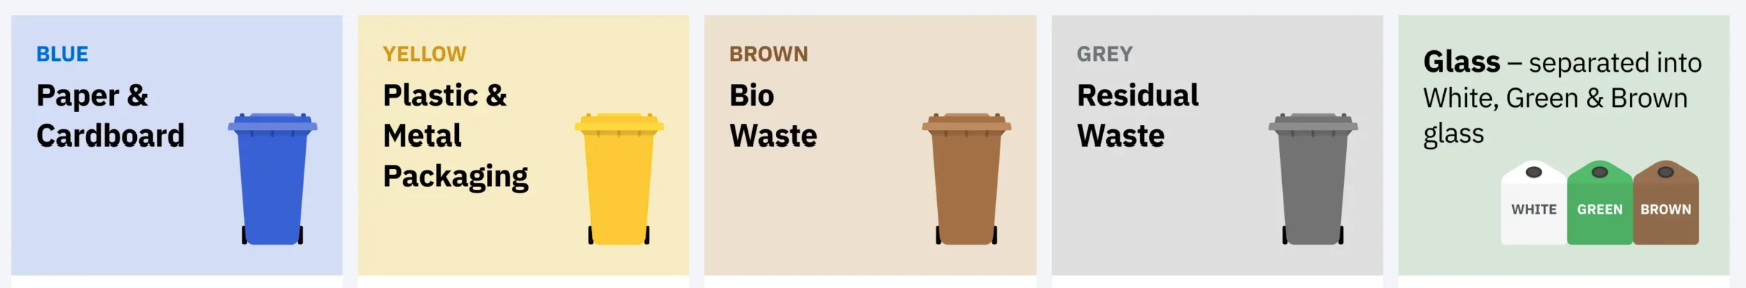

Based on the dataset chosen for this project, we have the following classifications of trash:

**paper, cardboard, plastic, metal, glass, compost, trash**

---



---



Importing all necessary modules needed for this project (not necessary to run, as in the below sections the main packages are imported again)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import os
import random
import warnings
warnings.filterwarnings('ignore')


Just to check if the code is working in colab.

In [6]:
x = 10
print(x**2)

100


# ***AI Model:***

***Loading training and testing dataset:***

As first step, import the datasets (garbage collection) that was downloaded/available from Kaggle. The images as datasets can be directly imported via
Kagglehub. It stores the datasets locally and gives the path to the location.


---

Once imported, the path to the folder and the content of the folders are checked using various output statements.




In [7]:
import os
import kagglehub

# Download dataset from KaggleHub and extract the path
path = kagglehub.dataset_download("vishallazrus/multi-class-garbage-classification-dataset")
print("Path to dataset files:", path)

for dirpath, dirnames, filenames in os.walk(path):
  print(f"There are {len(filenames)} images in '{dirpath}'.")

# Adjust path to point to the actual image folders
data_path = f"{path}/Multi class garbage classification"

# Point to test subfolder
test_path = os.path.join(path, "Multi class garbage classification/test/plastic")
print("Test path:", test_path)
# List all files
files = os.listdir(test_path)

# Filter only images (optional, in case there are extra files)
image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]

# Number of images
print(f"Number of images in test set: {len(image_files)}")

# Print first 10 file names
print("Sample files:", image_files[:10])


Using Colab cache for faster access to the 'multi-class-garbage-classification-dataset' dataset.
Path to dataset files: /kaggle/input/multi-class-garbage-classification-dataset
There are 0 images in '/kaggle/input/multi-class-garbage-classification-dataset'.
There are 1 images in '/kaggle/input/multi-class-garbage-classification-dataset/Multi class garbage classification'.
There are 0 images in '/kaggle/input/multi-class-garbage-classification-dataset/Multi class garbage classification/test'.
There are 40 images in '/kaggle/input/multi-class-garbage-classification-dataset/Multi class garbage classification/test/metal'.
There are 40 images in '/kaggle/input/multi-class-garbage-classification-dataset/Multi class garbage classification/test/glass'.
There are 38 images in '/kaggle/input/multi-class-garbage-classification-dataset/Multi class garbage classification/test/compost'.
There are 40 images in '/kaggle/input/multi-class-garbage-classification-dataset/Multi class garbage classificati

Once downloaded, using the path, the number of images in each folder is combed and checked (for information sake and checking if the dataset is completely downloaded)

---



---



***Training the model:***

Using the path (variable name 'data_path'), the dataset is loaded and training process is started with predefined models from *fastai*. At first, lower model (resnet34) is used with changing the epochs from 1 to 10. Later, higher model (resnet101) with 20 epochs is trained. The former has an accuracy of about 85%, where as the later has an accuracy of 93%.

In [8]:
from fastai.vision.all import *

# Create DataLoaders from the fastai package
dls = ImageDataLoaders.from_folder(
    data_path, # Use the adjusted path
    valid_pct=0.2,           # 20% for validation
    seed=42,                 # reproducibility
    item_tfms=Resize(224)    # resize images
)

# Define and train the model
#resnet34, resnet50
learn = vision_learner(dls, resnet152, metrics=accuracy)
learn.fine_tune(20)   # you can increase epochs

# Save the trained model
learn.export("/kaggle/garbage_classifier_resnet152_20.pkl")
print("Model saved as garbage_classifier.pkl")


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 192MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.482917,0.558294,0.829091,00:38


epoch,train_loss,valid_loss,accuracy,time
0,0.501314,0.365347,0.863636,00:53
1,0.350534,0.311317,0.892727,00:54
2,0.251670,0.288350,0.916364,00:54
3,0.182829,0.259668,0.929091,00:54
4,0.135225,0.260487,0.929091,00:54
5,0.101513,0.321638,0.914545,00:54
6,0.077217,0.354122,0.903636,00:54
7,0.057212,0.291396,0.920000,00:54
8,0.046562,0.342903,0.923636,00:54
9,0.040361,0.267243,0.929091,00:54


Model saved as garbage_classifier.pkl




---



---

***Prediction:***

Using the trained model and pick a single image from the testing dataset to check the prediction of our model.

In [9]:
# Predict on a single image (Only testing the image from the dataset collection)
def predict_image(img_path):
    img = PILImage.create(img_path)
    pred, pred_idx, probs = learn.predict(img)
    print(f"Prediction: {pred}; Probability: {probs[pred_idx]:.4f}")

# Example usage with the actual path to a test image inside the dataset
test_img = f"{data_path}/test/metal/metal154.jpg" # Example path to a valid image (selected based on print outputs from the kagglehub block from test folder)
predict_image(test_img)

Prediction: metal; Probability: 1.0000




---



---


***Saving the model:***

Exporting the trained model as '.pkl' file to the local machine.

In [10]:
from google.colab import files
files.download("/kaggle/garbage_classifier_resnet152_20.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---



---


# ***Loading the model:***

The above saved models can be loaded using the below section of the code. The model is selected and loaded, so that the user can directly use the model for predicting the trash instead of training the model everytime. This saves the time and computational power.

Uploading the downloaded AI model (.pkl) with 152 threads/layers (resnet152 model of fastai package with 20 epoch)

In [18]:
from google.colab import files

# Upload from your local machine
uploaded = files.upload()

Saving garbage_classifier_resnet152_20.pkl to garbage_classifier_resnet152_20.pkl


Uploading the downloaded AI model (.pkl) with 101 threads (resnet101 model of fastai package with 20 epoch)

In [ ]:
from google.colab import files

# Upload from your local machine - 101 version
#uploaded = files.upload()

Obtaining the path of the uploaded AI model (easy to understand and visualize)

In [19]:
import os

# List files in current directory
print(os.listdir())

# Absolute path of your .pkl
print("Full path:", os.path.abspath("*.pkl"))


['.config', '.gradio', 'garbage_classifier_resnet152_20.pkl', 'garbage_classifier_resnet101_20.pkl', 'sample_data']
Full path: /content/*.pkl


Once uploaded from the above section of code, the model is loaded and checked for the classes (different types of trash that was trained in the model). The check is to know the types that can be expected from this current model.

In [20]:
from fastai.vision.all import *

# Load back the exported learner
#learn = load_learner("/content/garbage_classifier_resnet34_10.pkl")
#learn = load_learner("/content/garbage_classifier_resnet101_20.pkl")
learn = load_learner("/content/garbage_classifier_resnet152_20.pkl")
# Confirm classes
print("Classes:", learn.dls.vocab)

Classes: ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']


# ***User-Interface:***

After training the model, the usage of that model to predict the classification of the image is quite straight forward. But, it is not user-friendly to place the user-image in a folder and choose the path of it for code.

Therefore, a user-interface is created to upload the image and upon submission it triggers directly the model to predict the classification of the uploaded user-image. It also provides the top 3 hits with highest order of probability.

As an example, the user interface looks like the following image: Image uploader (left) and the model prediction (right)

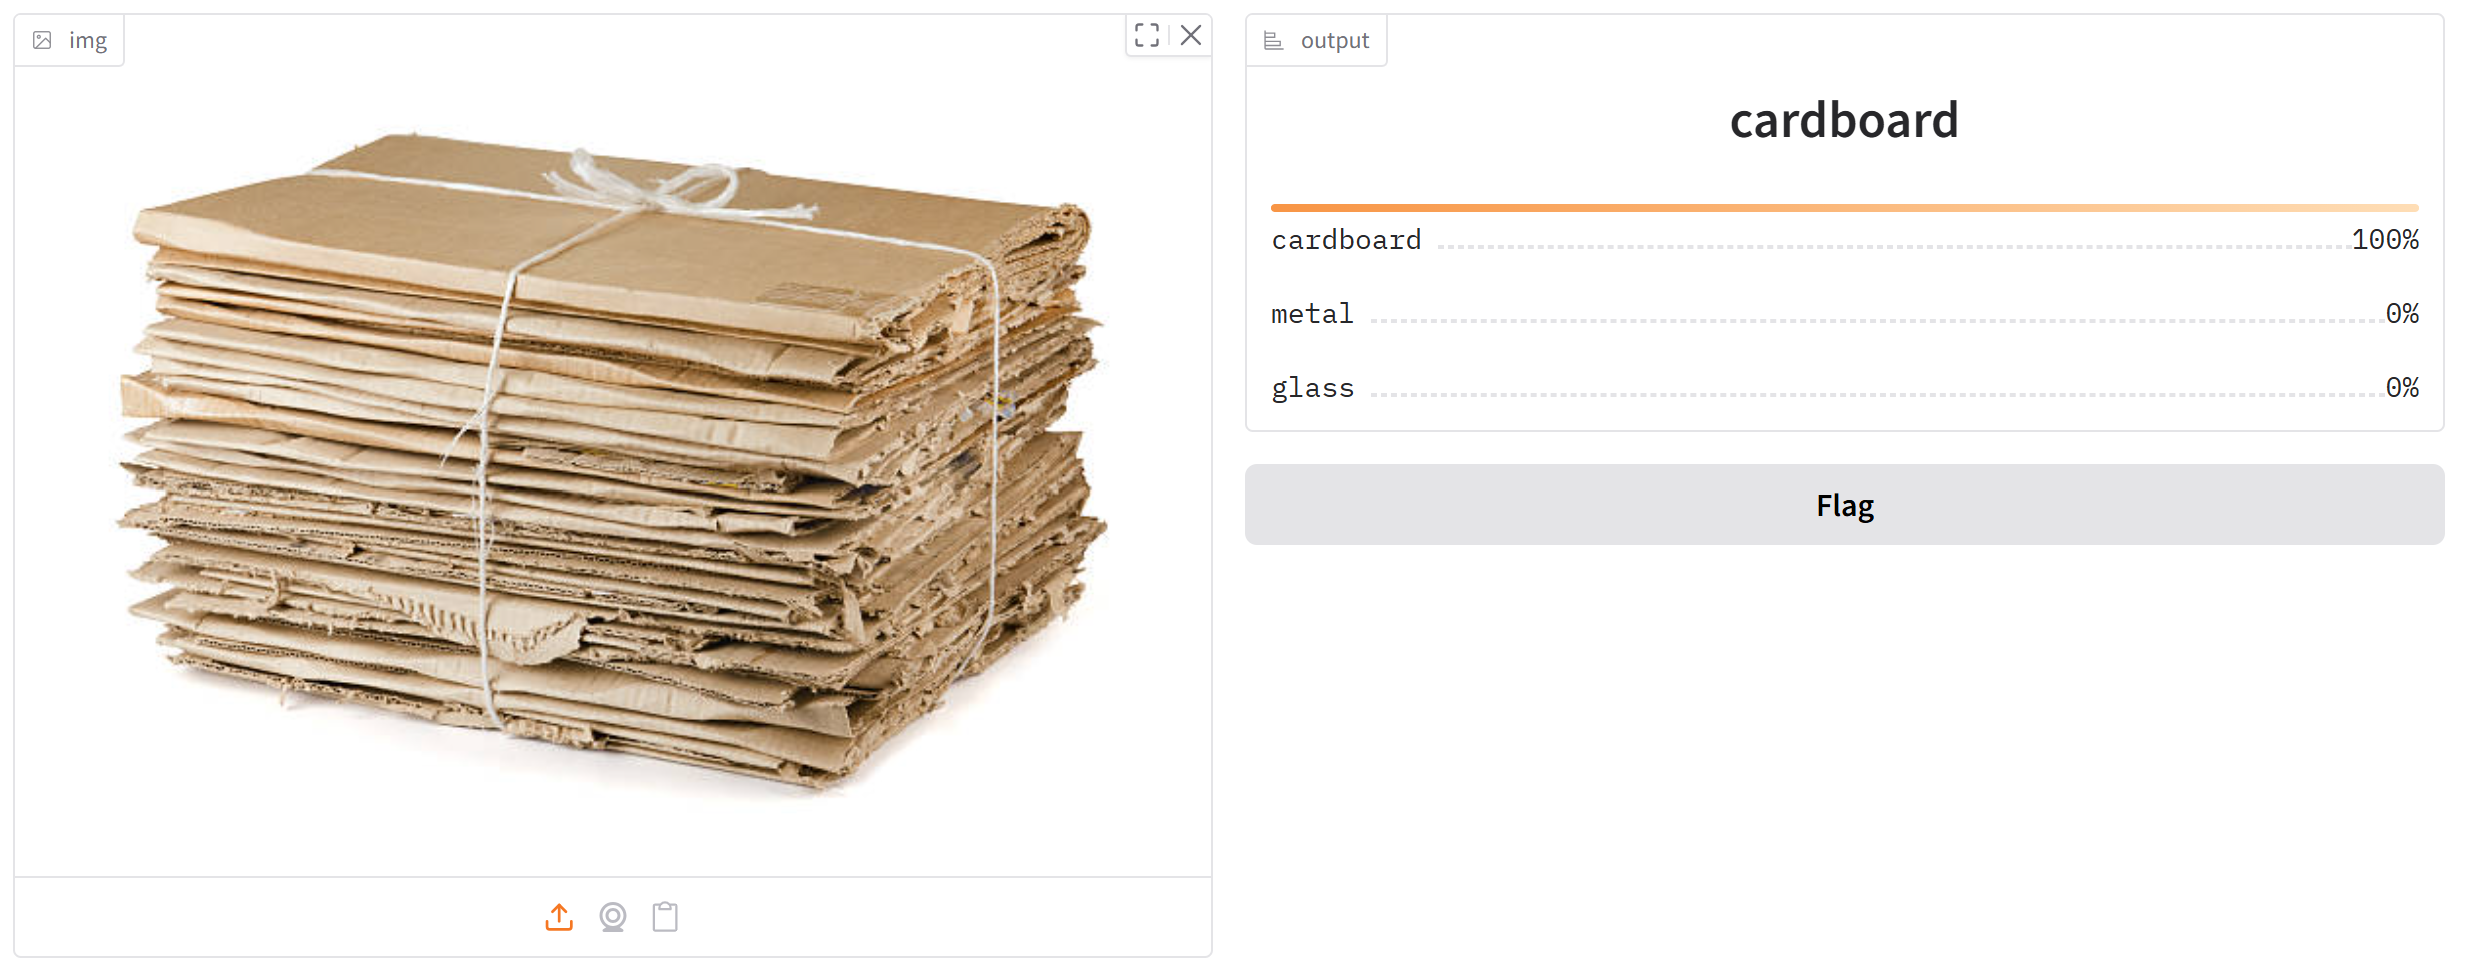

In [22]:
import gradio as gr
from fastai.vision.all import *

# Load trained model (exported as .pkl earlier)
learn = load_learner("/content/garbage_classifier_resnet152_20.pkl")

# Prediction function
def classify_image(img):
    pred, pred_idx, probs = learn.predict(img)
    return {c: float(probs[i]) for i, c in enumerate(learn.dls.vocab)}

# Create UI
demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Garbage Classifier",
    description="Upload an image of waste (plastic, glass, cardboard, etc.) and the AI will classify it."
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c841ffacdfceaede3b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Output 1: (plastic bottles)

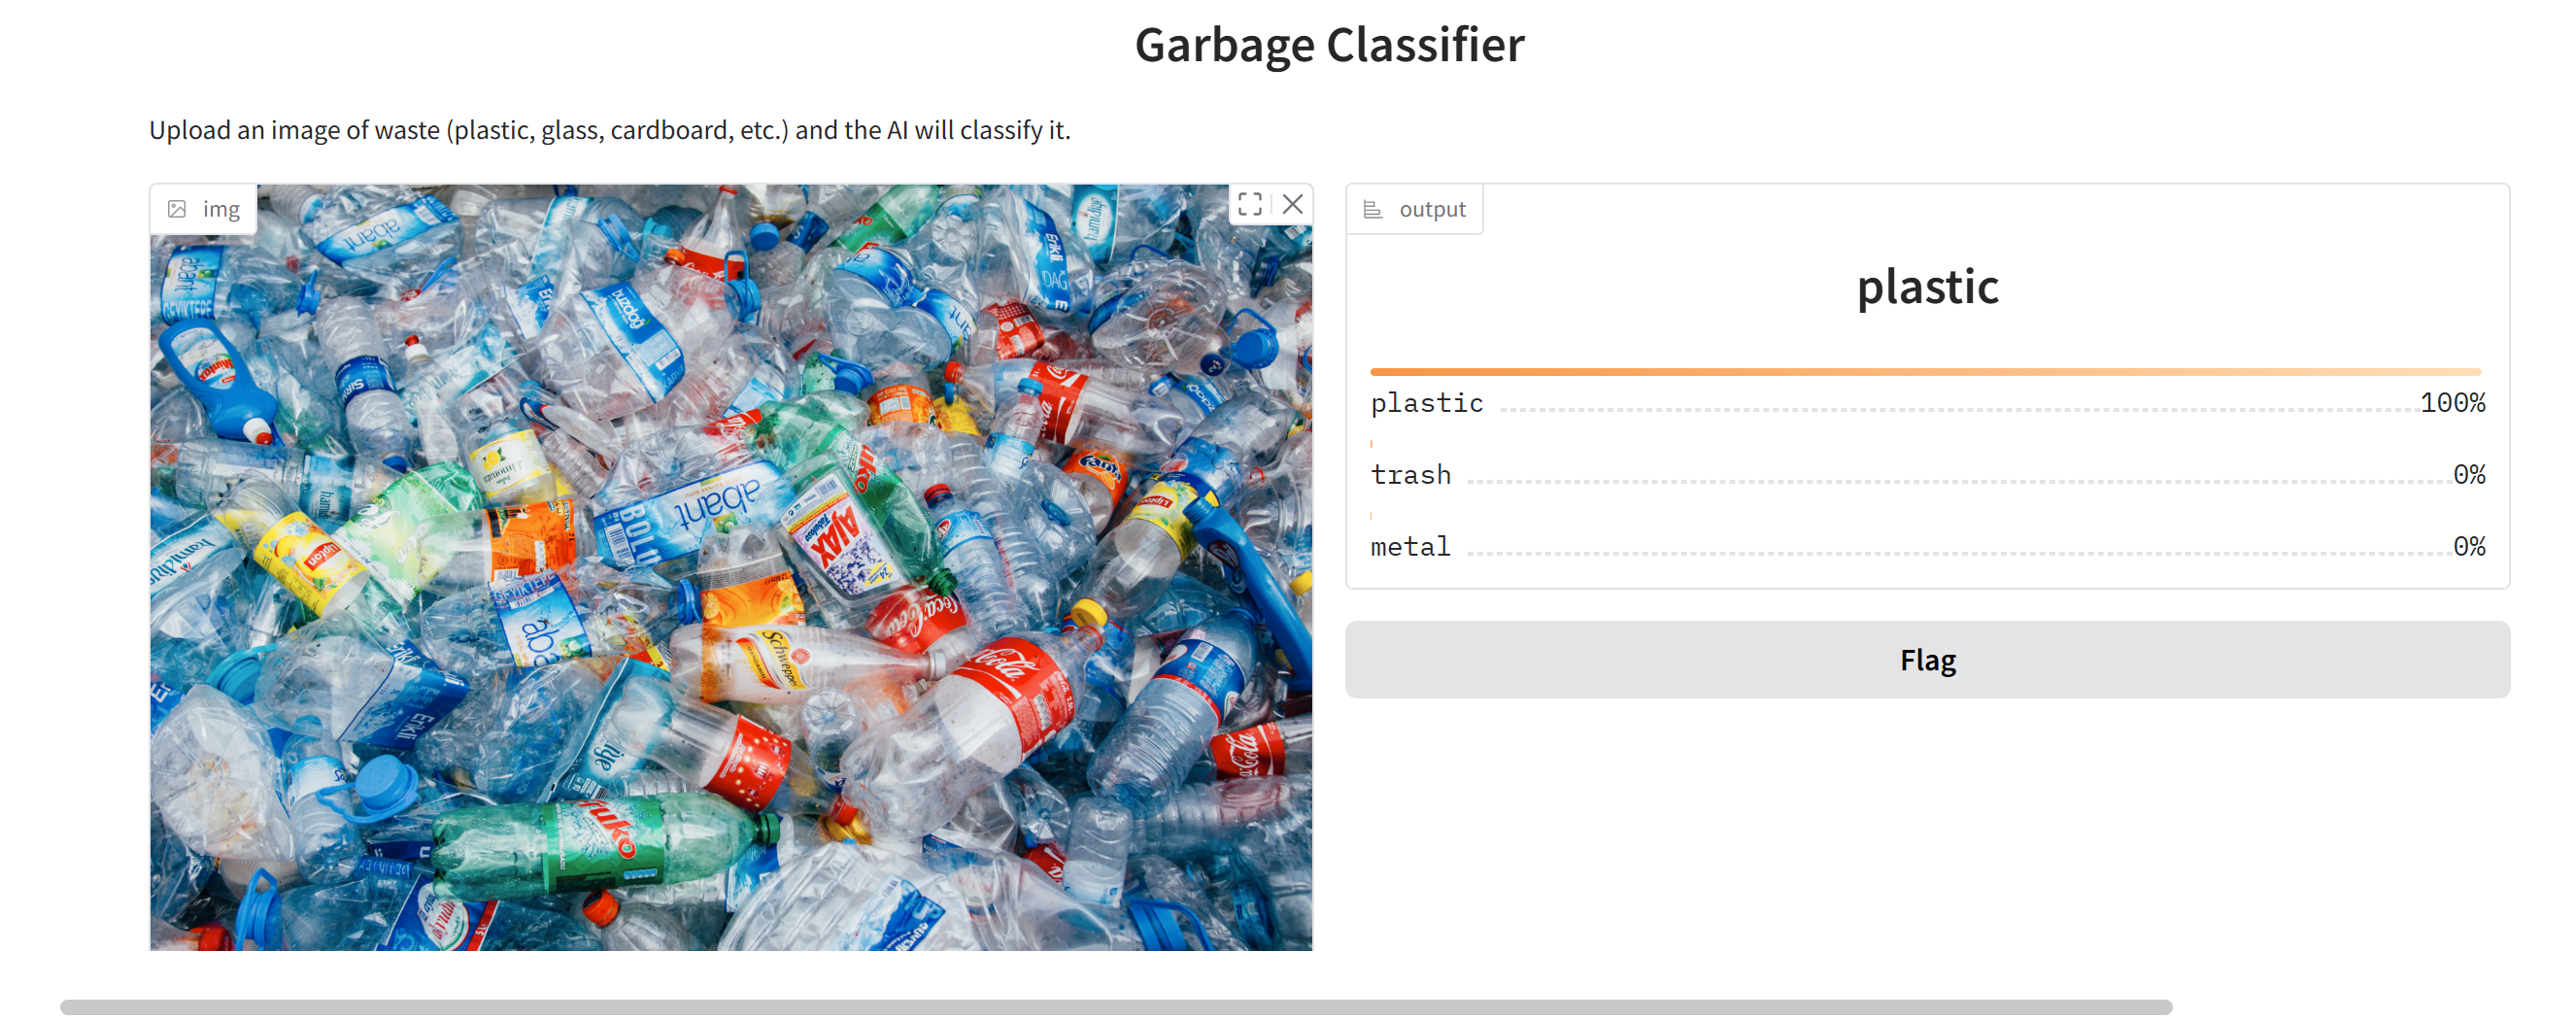

# Output 2: (metal products)

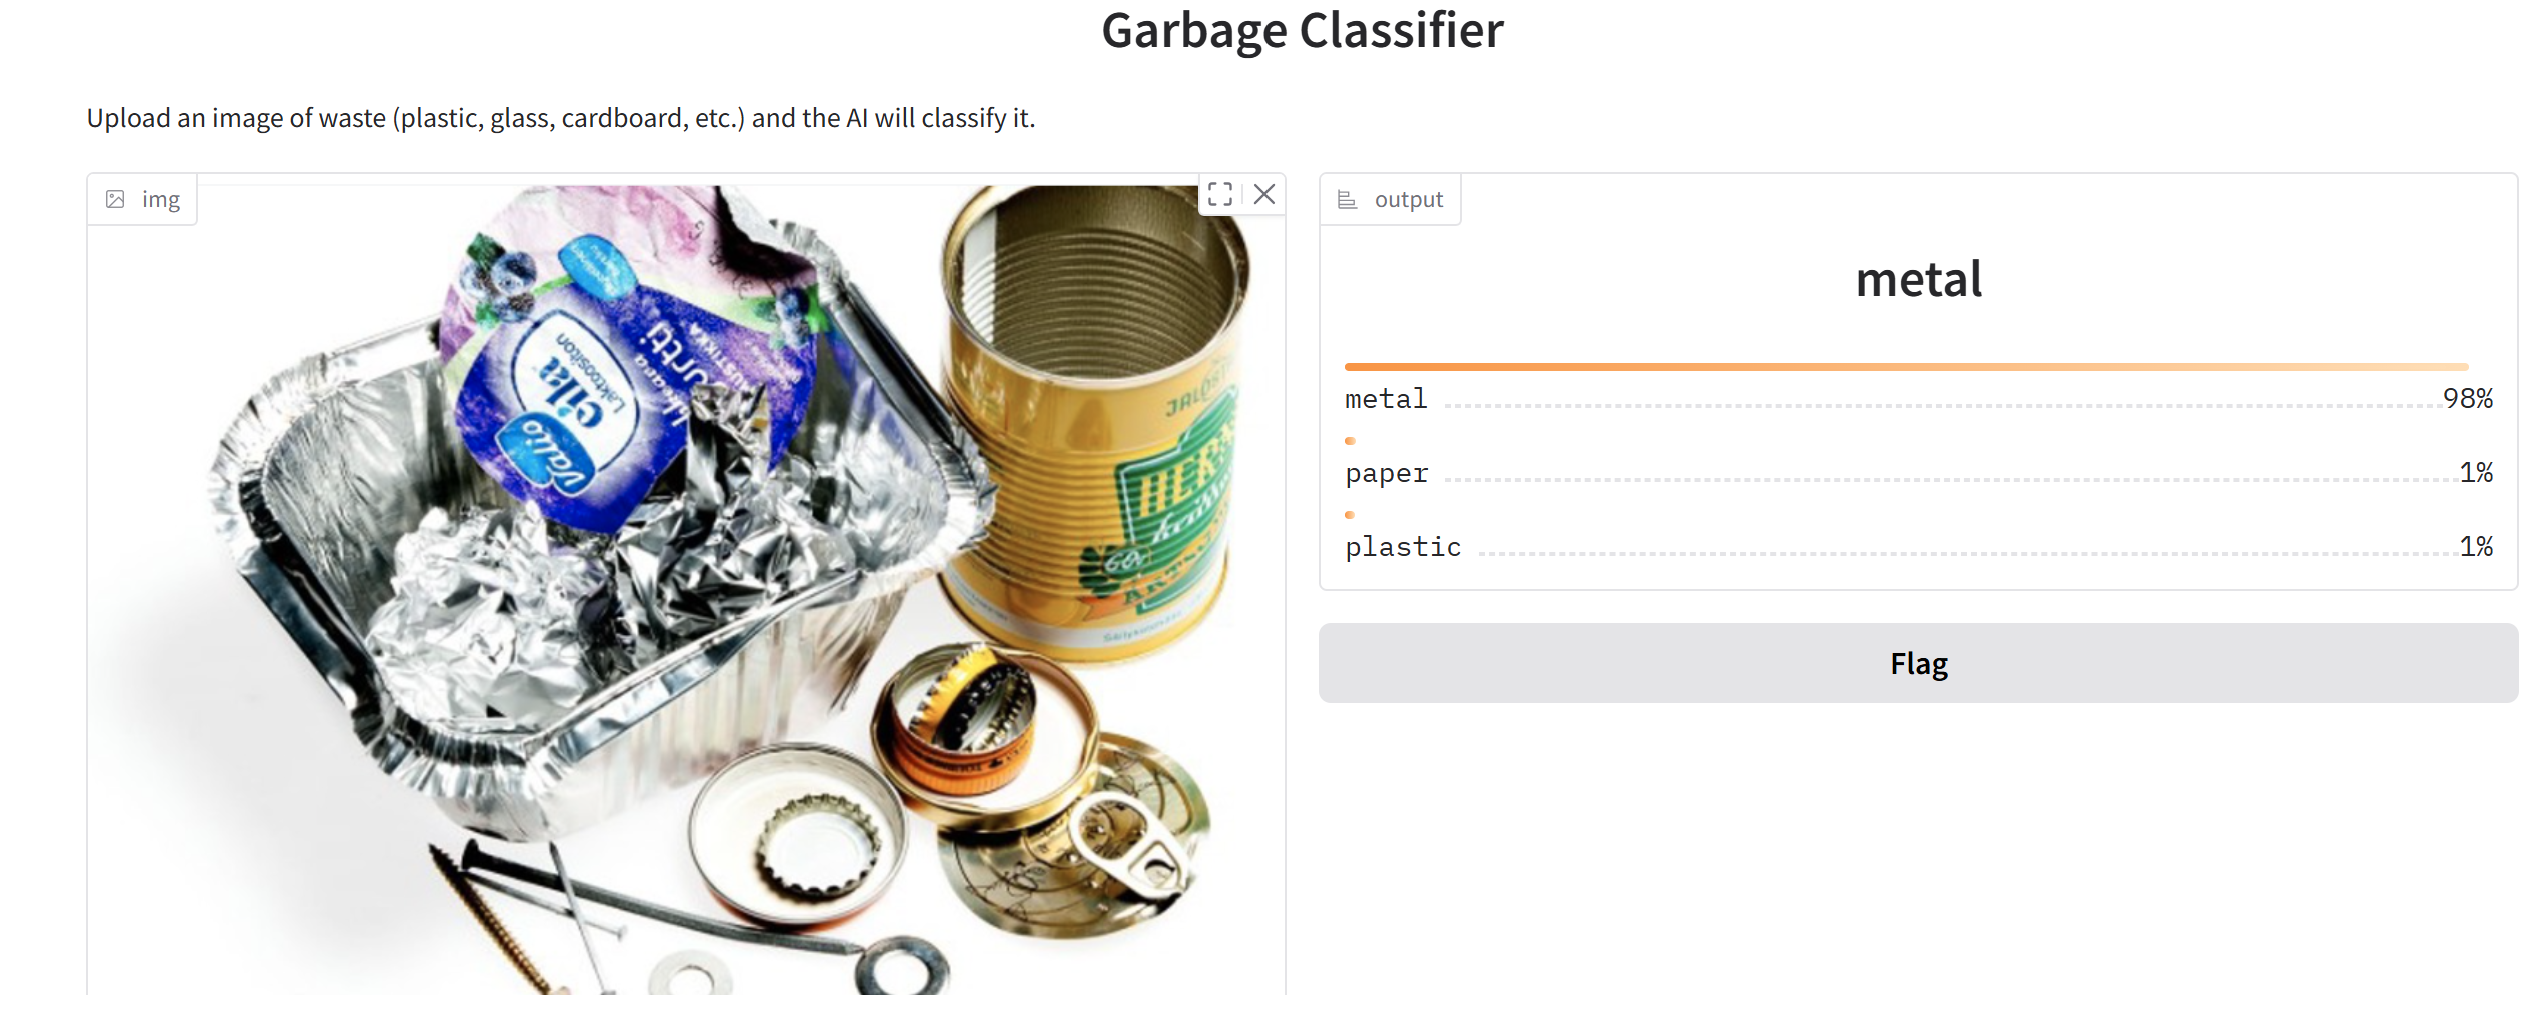